In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
X , y  = make_blobs(n_samples=700, centers = 3, cluster_std=1, random_state= 42)

In [ ]:
df = pd.DataFrame(X, columns=['x1', 'x2'])

In [ ]:
df

,x1,x2
0,3.241311,2.536139
1,4.602244,3.076472
2,-8.282232,-5.130533
3,-8.873363,-6.506053
4,5.807661,2.227591
...,...,...
695,-7.869255,-5.939338
696,4.012912,3.785618
697,-6.576992,-7.634385
698,4.084679,3.854327


In [ ]:
scaler = StandardScaler()
x_scaler = scaler.fit_transform(df)

In [ ]:
inertia = []
k_range = range(1,11)

In [ ]:
for k in range(1,11) :
  kmeans = KMeans(n_clusters=k,random_state=42)
  kmeans.fit(x_scaler)
  inertia.append(kmeans.inertia_)

In [ ]:
print(inertia)

[1399.9999999999993, 436.83940867086744, 44.48966790325015, 38.50485305173727, 32.87951034487385, 27.212057713762174, 24.70374204363249, 22.571697227912495, 20.49135165016086, 17.727807093117864]


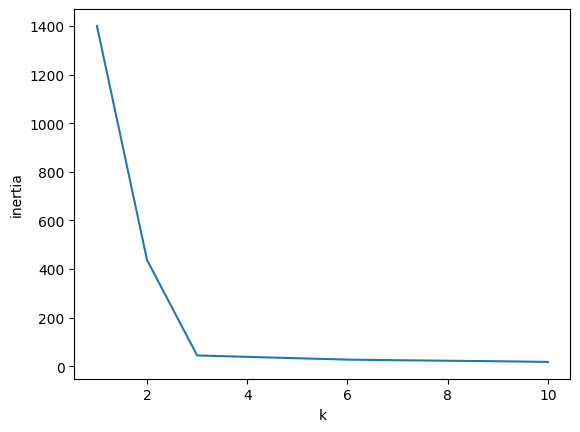

In [ ]:
plt.plot(k_range , inertia)
plt.xlabel('k')
plt.ylabel('inertia')
plt.show()

In [ ]:
final_modal = KMeans(n_clusters=3,random_state=42)
final_modal.fit(x_scaler)

KMeans(n_clusters=3, random_state=42)

In [ ]:
cluster = final_modal.fit_predict(x_scaler)

In [ ]:
df["cluser"] =  cluster


In [ ]:
df

,x1,x2,cluser
0,3.241311,2.536139,2
1,4.602244,3.076472,2
2,-8.282232,-5.130533,0
3,-8.873363,-6.506053,0
4,5.807661,2.227591,2
...,...,...,...
695,-7.869255,-5.939338,0
696,4.012912,3.785618,2
697,-6.576992,-7.634385,0
698,4.084679,3.854327,2


<Axes: xlabel='x1', ylabel='x2'>

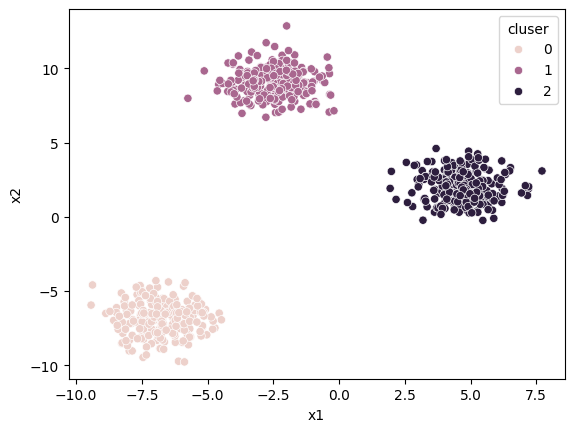

In [ ]:
sns.scatterplot(x='x1',y='x2',hue='cluser',data=df)
#

#### DBSCAN


In [ ]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

In [ ]:
X , y = make_moons(n_samples=400, noise=0.05, random_state=42)

In [ ]:
df = pd.DataFrame(X, columns=['x1', 'x2'])

In [ ]:
df

,x1,x2
0,-0.016988,0.397237
1,0.694613,-0.427054
2,0.847768,0.519621
3,0.095624,0.305824
4,0.097075,0.970429
...,...,...
395,0.429858,0.975407
396,-0.018152,0.971725
397,0.637550,-0.339747
398,1.811444,-0.242124


In [ ]:
X_scaled2 = StandardScaler().fit_transform(df)

In [ ]:
# if appay k_means

kmeans2 = KMeans(n_clusters=2, random_state=42)
labal2 = kmeans2.fit_predict(X_scaled2)

In [ ]:
df["k_labal"] = labal2

In [ ]:
df


,x1,x2,k_labal
0,-0.016988,0.397237,1
1,0.694613,-0.427054,0
2,0.847768,0.519621,1
3,0.095624,0.305824,1
4,0.097075,0.970429,1
...,...,...,...
395,0.429858,0.975407,1
396,-0.018152,0.971725,1
397,0.637550,-0.339747,0
398,1.811444,-0.242124,0


<Axes: xlabel='x1', ylabel='x2'>

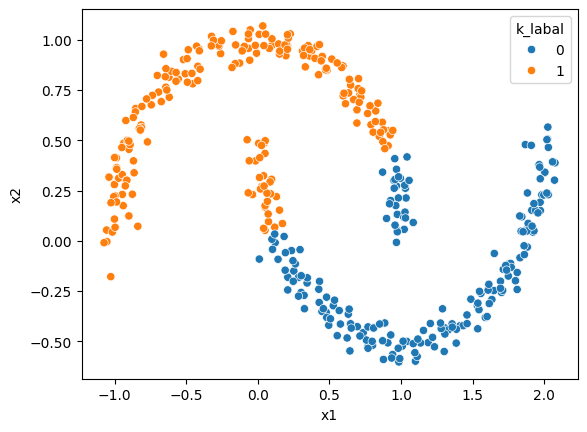

In [ ]:
sns.scatterplot(x='x1',y='x2',hue='k_labal',data=df)
#

In [ ]:
dbscan = DBSCAN(eps=0.2, min_samples=5)

In [ ]:
dbscan_labal = dbscan.fit_predict(X_scaled2)

In [ ]:
df["db_labal"] = dbscan_labal

In [ ]:
df

,x1,x2,k_labal,db_labal
0,-0.016988,0.397237,1,0
1,0.694613,-0.427054,0,0
2,0.847768,0.519621,1,1
3,0.095624,0.305824,1,0
4,0.097075,0.970429,1,1
...,...,...,...,...
395,0.429858,0.975407,1,1
396,-0.018152,0.971725,1,1
397,0.637550,-0.339747,0,0
398,1.811444,-0.242124,0,0


<Axes: xlabel='x1', ylabel='x2'>

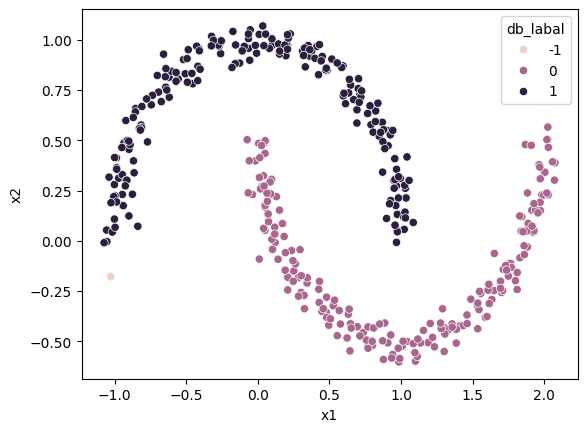

In [ ]:
sns.scatterplot(x='x1',y='x2',hue='db_labal',data=df)
#

In [ ]:
dbscan_labal = dbscan.fit_predict(X_scaled2)

In [ ]:
df["db_labal"] = dbscan_labal

In [ ]:
df

,x1,x2,k_labal,db_labal
0,-0.016988,0.397237,1,0
1,0.694613,-0.427054,0,0
2,0.847768,0.519621,1,1
3,0.095624,0.305824,1,0
4,0.097075,0.970429,1,1
...,...,...,...,...
395,0.429858,0.975407,1,1
396,-0.018152,0.971725,1,1
397,0.637550,-0.339747,0,0
398,1.811444,-0.242124,0,0


<Axes: xlabel='x1', ylabel='x2'>

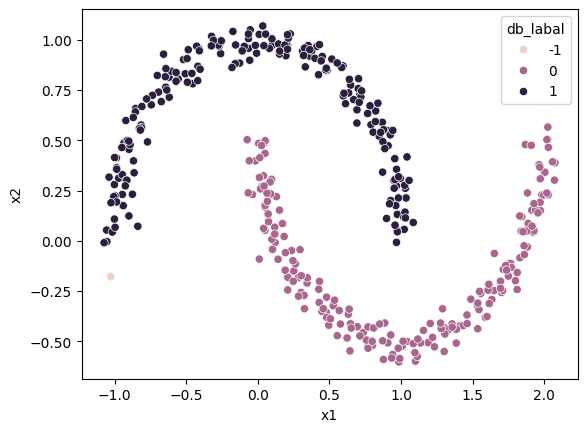

In [ ]:
sns.scatterplot(x='x1',y='x2',hue='db_labal',data=df)

In [ ]:
print(df['db_labal'].unique())
print(f"Number of unique DBSCAN labels (including noise): {len(df['db_labal'].unique())}")

[ 0  1 -1]
Number of unique DBSCAN labels (including noise): 3


In [ ]:
print(df['db_labal'].unique())
print(f"Number of unique DBSCAN labels (including noise): {len(df['db_labal'].unique())}")

[ 0  1 -1]
Number of unique DBSCAN labels (including noise): 3


DBSCAN assigns a label of -1 to noise points. Any other unique positive integer represents a distinct cluster. The number of unique labels from the output above, excluding -1, will be the number of identified clusters.